In [1]:
import pandas as pd

In [2]:
data = pd.read_csv("ames_housing.csv")

In [14]:
data.isnull().sum()

Order             0
PID               0
MS SubClass       0
MS Zoning         0
Lot Frontage      3
                 ..
Mo Sold           0
Yr Sold           0
Sale Type         0
Sale Condition    0
SalePrice         0
Length: 78, dtype: int64

In [15]:
data['Mas Vnr Type'] = data['Mas Vnr Type'].fillna('None')
data['Fireplace Qu'] = data['Fireplace Qu'].fillna('None')

In [19]:
data.columns = data.columns.str.strip()
print([col for col in data.columns if 'Bsmt' in col])

['Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1', 'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', 'Bsmt Full Bath', 'Bsmt Half Bath']


In [20]:
data['Lot Frontage'] = data.groupby('Neighborhood')['Lot Frontage'].transform(lambda x: x.fillna(x.median()))

In [21]:
cols_to_drop = ['Pool QC', 'Misc Feature', 'Alley', 'Fence']
data = data.drop(columns=[c for c in cols_to_drop if c in data.columns])


cat_cols = ['Garage Type', 'Garage Finish', 'Garage Qual', 'Garage Cond', 
            'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2', 'Bsmt Cond', 'Bsmt Qual']

existing_cat_cols = [c for c in cat_cols if c in data.columns]
data[existing_cat_cols] = data[existing_cat_cols].fillna('None')


num_cols = ['Garage Yr Blt', 'Mas Vnr Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 
            'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', 'Garage Cars', 'Garage Area']

existing_num_cols = [c for c in num_cols if c in data.columns]
data[existing_num_cols] = data[existing_num_cols].fillna(0)


print(f"Remaining nulls: {data.isnull().sum().sum()}")

Remaining nulls: 4


In [22]:
null_series = data.isnull().sum()
print(null_series[null_series > 0])

Lot Frontage    3
Electrical      1
dtype: int64


In [23]:
data['Lot Frontage'] = data['Lot Frontage'].fillna(data['Lot Frontage'].median())

data['Electrical'] = data['Electrical'].fillna(data['Electrical'].mode()[0])

print(f"Total remaining nulls: {data.isnull().sum().sum()}")

Total remaining nulls: 0


In [24]:
correlations = data.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)

print("Top 10 Features Correlated with SalePrice:")
print(correlations.head(11))

Top 10 Features Correlated with SalePrice:
SalePrice         1.000000
Overall Qual      0.799262
Gr Liv Area       0.706780
Garage Cars       0.647562
Garage Area       0.640138
Total Bsmt SF     0.632529
1st Flr SF        0.621676
Year Built        0.558426
Full Bath         0.545604
Year Remod/Add    0.532974
Mas Vnr Area      0.502196
Name: SalePrice, dtype: float64


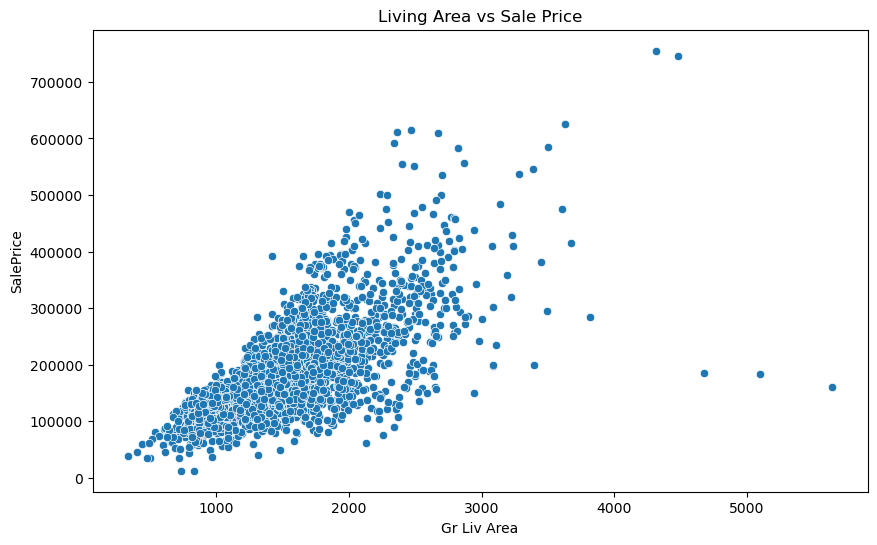

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Gr Liv Area', y='SalePrice', data=data)
plt.title('Living Area vs Sale Price')
plt.show()

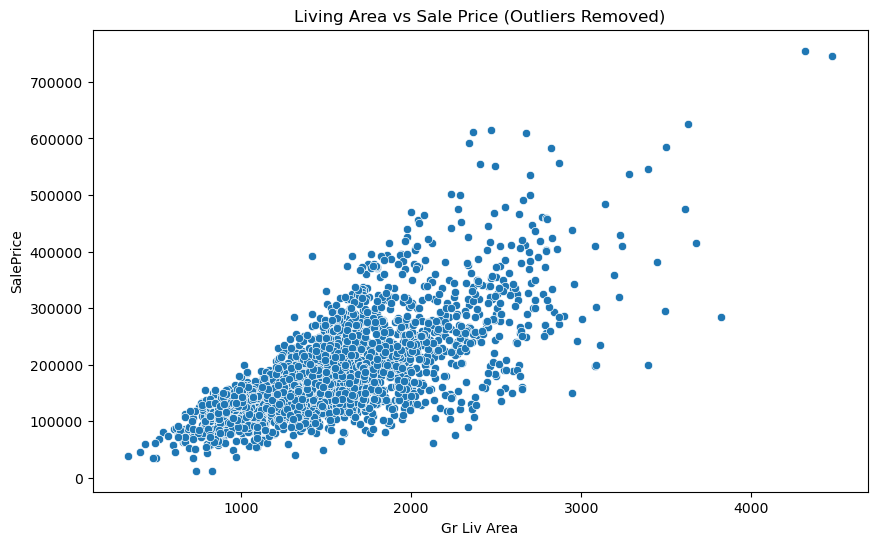

In [26]:
outliers = data[(data['Gr Liv Area'] > 4000) & (data['SalePrice'] < 200000)].index
data = data.drop(outliers, axis=0)

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Gr Liv Area', y='SalePrice', data=data)
plt.title('Living Area vs Sale Price (Outliers Removed)')
plt.show()

In [28]:
df_final = pd.get_dummies(data, drop_first=True)
X = df_final.drop('SalePrice', axis=1)
y = df_final['SalePrice']

print(f"New feature count after encoding: {X.shape[1]}")

New feature count after encoding: 261


In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=101)

print("Data is split and ready for the model!")

Data is split and ready for the model!


In [36]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso

final_model = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(alpha=100, max_iter=100000))
])

final_model.fit(X_train, y_train)


final_preds = final_model.predict(X_test)

In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, final_preds)
rmse = np.sqrt(mean_squared_error(y_test, final_preds))
r2 = r2_score(y_test, final_preds)

print(f"Final Lasso MAE: ${mae:,.2f}")
print(f"Final Lasso RMSE: ${rmse:,.2f}")
print(f"Final Lasso R2 Score: {r2:.4f}")

Final Lasso MAE: $15,033.48
Final Lasso RMSE: $21,706.72
Final Lasso R2 Score: 0.9192


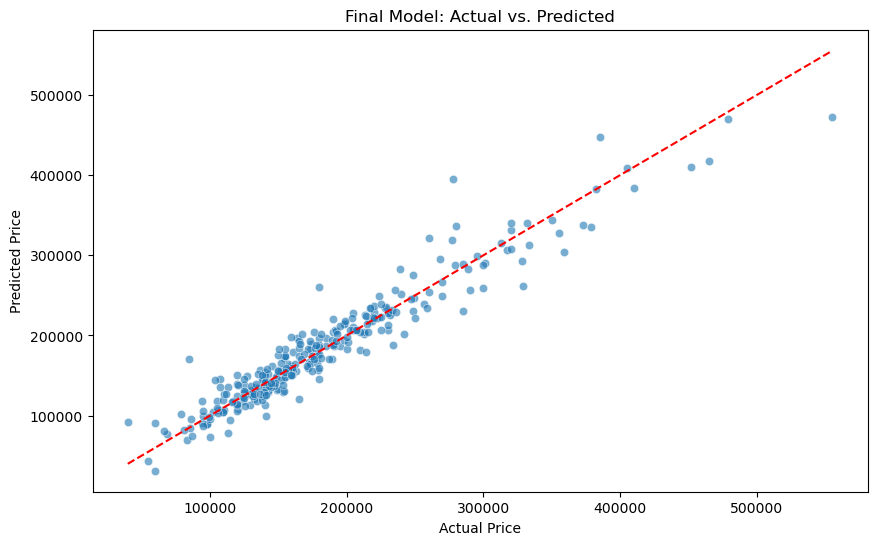

In [38]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=final_preds, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Final Model: Actual vs. Predicted')
plt.show()

In [41]:
from xgboost import XGBRegressor

xgb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=101))
])


xgb_param_grid = {
    'xgb__n_estimators': [500, 1000],
    'xgb__learning_rate': [0.01, 0.05, 0.1],
    'xgb__max_depth': [3, 5, 6]
}


xgb_grid = GridSearchCV(estimator=xgb_pipeline,
                        param_grid=xgb_param_grid,
                        cv=5,
                        scoring='neg_mean_absolute_error',
                        n_jobs=-1, 
                        verbose=1)


xgb_grid.fit(X_train, y_train)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'xgb__learning_rate': [0.01, 0.05, ...], 'xgb__max_depth': [3, 5, ...], 'xgb__n_estimators': [500, 1000]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and par

In [42]:
xgb_preds = xgb_grid.predict(X_test)


xgb_mae = mean_absolute_error(y_test, xgb_preds)
xgb_r2 = r2_score(y_test, xgb_preds)

print(f"Best XGB Params: {xgb_grid.best_params_}")
print(f"XGBoost MAE: ${xgb_mae:,.2f}")
print(f"XGBoost R2 Score: {xgb_r2:.4f}")


print(f"\nDifference vs Lasso: ${15033.48 - xgb_mae:,.2f}")

Best XGB Params: {'xgb__learning_rate': 0.1, 'xgb__max_depth': 3, 'xgb__n_estimators': 1000}
XGBoost MAE: $13,317.44
XGBoost R2 Score: 0.9291

Difference vs Lasso: $1,716.04


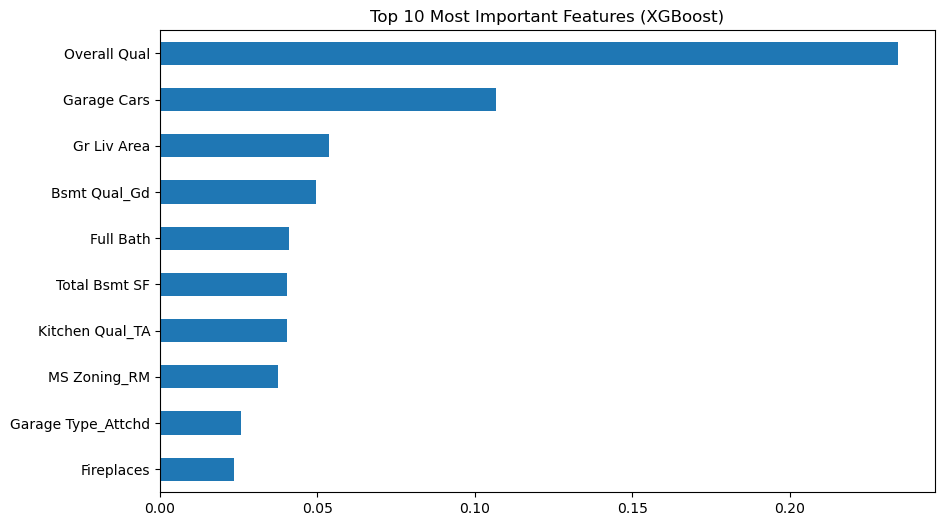

In [43]:
import matplotlib.pyplot as plt


importances = xgb_grid.best_estimator_.named_steps['xgb'].feature_importances_
feature_names = X.columns
importance_df = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10,6))
importance_df.head(10).plot(kind='barh')
plt.title('Top 10 Most Important Features (XGBoost)')
plt.gca().invert_yaxis()
plt.show()

In [44]:
import joblib
final_xgb_model = xgb_grid.best_estimator_
joblib.dump(final_xgb_model, 'ames_housing_xgb_model.pkl')


joblib.dump(list(X.columns), 'model_features.pkl')

print("Champion XGBoost model and features saved successfully!")

Champion XGBoost model and features saved successfully!
